# 第四部分：描述性统计与可视化（03_analysis）

这个 notebook 对应作业第四部分，默认读取你在前面步骤已经生成好的文件：

- `data/clean/stock_clean.csv`
- `data/index/index_000300.csv`
- `data/macro/macro_cpi_yoy.csv` 或 `data/macro/macro_lpr_1y.csv`
- `data/finance/finance_long.csv`
- `data/stock/stock_universe.csv`（如存在）

运行完成后会：

1. 计算 10 只股票日收益率的描述性统计表  
2. 生成图 1–4（必做）与图 5（选做）  
3. 将所有图片以 PNG 格式保存到 `output/`，分辨率为 200 dpi  
4. 将描述性统计表保存到 `output/descriptive_stats.csv`

如果你的股票池与我之前给你的 10 只股票不同，也可以直接运行；只要 `stock_clean.csv` 和 `stock_universe.csv` 中的代码对应即可。

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
CLEAN_DIR = DATA_DIR / "clean"
INDEX_DIR = DATA_DIR / "index"
MACRO_DIR = DATA_DIR / "macro"
FINANCE_DIR = DATA_DIR / "finance"
STOCK_DIR = DATA_DIR / "stock"
OUTPUT_DIR = ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

def show_text(title, sentences):
    text = f"**{title} 图后解读：**\n\n"
    for i, s in enumerate(sentences, 1):
        text += f"{i}. {s}\n\n"
    display(Markdown(text))

def safe_read_csv(path, **kwargs):
    if not Path(path).exists():
        raise FileNotFoundError(f"未找到文件：{path}")
    return pd.read_csv(path, **kwargs)

In [2]:
# 读取股票清洗后数据
stock_path = CLEAN_DIR / "stock_clean.csv"
stock_df = safe_read_csv(stock_path)
stock_df["date"] = pd.to_datetime(stock_df["date"])
stock_df["code"] = stock_df["code"].astype(str).str.zfill(6)

# 读取股票清单（如果存在）
universe_path = STOCK_DIR / "stock_universe.csv"
if universe_path.exists():
    universe = pd.read_csv(universe_path)
    universe["code"] = universe["code"].astype(str).str.zfill(6)
else:
    universe = pd.DataFrame({
        "code": ["600036","601398","000625","600104","600519","000858","600028","601857","600050","000063"],
        "name": ["招商银行","工商银行","长安汽车","上汽集团","贵州茅台","五粮液","中国石化","中国石油","中国联通","中兴通讯"],
        "industry": ["银行","银行","汽车","汽车","白酒","白酒","能源","能源","通讯","通讯"]
    })

# 补齐股票名称和行业
if "name" not in stock_df.columns or "industry" not in stock_df.columns:
    stock_df = stock_df.merge(universe[["code", "name", "industry"]], on="code", how="left")

# 读取沪深300
hs300_path = INDEX_DIR / "index_000300.csv"
hs300 = safe_read_csv(hs300_path)
hs300["date"] = pd.to_datetime(hs300["date"])
hs300["code"] = hs300["code"].astype(str).str.zfill(6)

# 读取宏观指标
macro_candidates = []
for p in [MACRO_DIR / "macro_cpi_yoy.csv", MACRO_DIR / "macro_lpr_1y.csv"]:
    if p.exists():
        tmp = pd.read_csv(p)
        tmp["date"] = pd.to_datetime(tmp["date"])
        macro_candidates.append(tmp)

# 读取财务数据
finance_path = FINANCE_DIR / "finance_long.csv"
finance_df = pd.read_csv(finance_path) if finance_path.exists() else pd.DataFrame()
if not finance_df.empty:
    finance_df["code"] = finance_df["code"].astype(str).str.zfill(6)

print("stock_df:", stock_df.shape)
print("hs300:", hs300.shape)
print("宏观指标文件数:", len(macro_candidates))
print("finance_df:", finance_df.shape)

stock_df: (15139, 12)
hs300: (1514, 8)
宏观指标文件数: 2
finance_df: (100, 4)


## 4.1 基本统计量

下面计算 10 只股票日收益率的描述性统计量。作业要求使用  
$r_t = \ln(P_t / P_{t-1})$，因此这里以**对数收益率**作为基础变量，并输出：

- 年化均值
- 年化波动率
- 偏度
- 峰度
- 最大回撤

结果会同时显示在 notebook 中，并保存到 `output/descriptive_stats.csv`。

In [3]:
# 计算日对数收益率
stock_df = stock_df.sort_values(["code", "date"]).copy()
stock_df["log_return"] = stock_df.groupby("code")["close"].transform(lambda s: np.log(s / s.shift(1)))

# 最大回撤函数（基于收盘价序列）
def max_drawdown(price_series):
    price = pd.to_numeric(price_series, errors="coerce").dropna()
    if price.empty:
        return np.nan
    wealth = price / price.iloc[0]
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    return drawdown.min()

# 计算描述性统计
rows = []
meta = stock_df[["code", "name", "industry"]].drop_duplicates().sort_values(["industry", "code"])

for _, row in meta.iterrows():
    code_ = row["code"]
    name_ = row["name"]
    industry_ = row["industry"]
    sub = stock_df.loc[stock_df["code"] == code_, ["date", "close", "log_return"]].copy()
    r = sub["log_return"].dropna()

    annual_mean = r.mean() * 252
    annual_vol = r.std() * np.sqrt(252)
    skewness = r.skew()
    kurtosis = r.kurt()
    mdd = max_drawdown(sub["close"])

    rows.append({
        "股票": name_,
        "代码": code_,
        "行业": industry_,
        "年化均值": annual_mean,
        "年化波动率": annual_vol,
        "偏度": skewness,
        "峰度": kurtosis,
        "最大回撤": mdd,
    })

stats_df = pd.DataFrame(rows).sort_values(["行业", "代码"]).reset_index(drop=True)
display(stats_df)

stats_out = OUTPUT_DIR / "descriptive_stats.csv"
stats_df.to_csv(stats_out, index=False, encoding="utf-8-sig")
print("已保存：", stats_out)

,股票,代码,行业,年化均值,年化波动率,偏度,峰度,最大回撤
0,长安汽车,000625,汽车,0.102386,0.480105,0.322048,2.150256,-0.599558
1,上汽集团,600104,汽车,-0.060221,0.317191,0.337540,5.274071,-0.539865
2,五粮液,000858,白酒,-0.012957,0.345522,0.087607,3.312187,-0.660939
3,贵州茅台,600519,白酒,0.066558,0.277019,0.261764,3.614534,-0.474821
4,中国石化,600028,能源,0.084676,0.233507,0.355994,5.365962,-0.250639
5,中国石油,601857,能源,0.172464,0.292666,0.219764,5.173800,-0.324707
6,中兴通讯,000063,通讯,-0.003283,0.426226,0.309737,2.479031,-0.618671
7,中国联通,600050,通讯,-0.024059,0.290195,0.900915,7.505944,-0.435733
8,招商银行,600036,银行,0.048576,0.277347,0.263830,3.150626,-0.509439
9,工商银行,601398,银行,0.094680,0.162723,0.455532,5.831962,-0.202024


已保存： d:\Microsoft VS Code\dshw-p01\output\descriptive_stats.csv


## 4.2 图 1：归一化收盘价走势图

要求：

- 10 只股票以 2020-01-01 = 1 为基准进行归一化
- 叠加沪深 300 指数
- 图例按行业分组着色
- 写图后解读

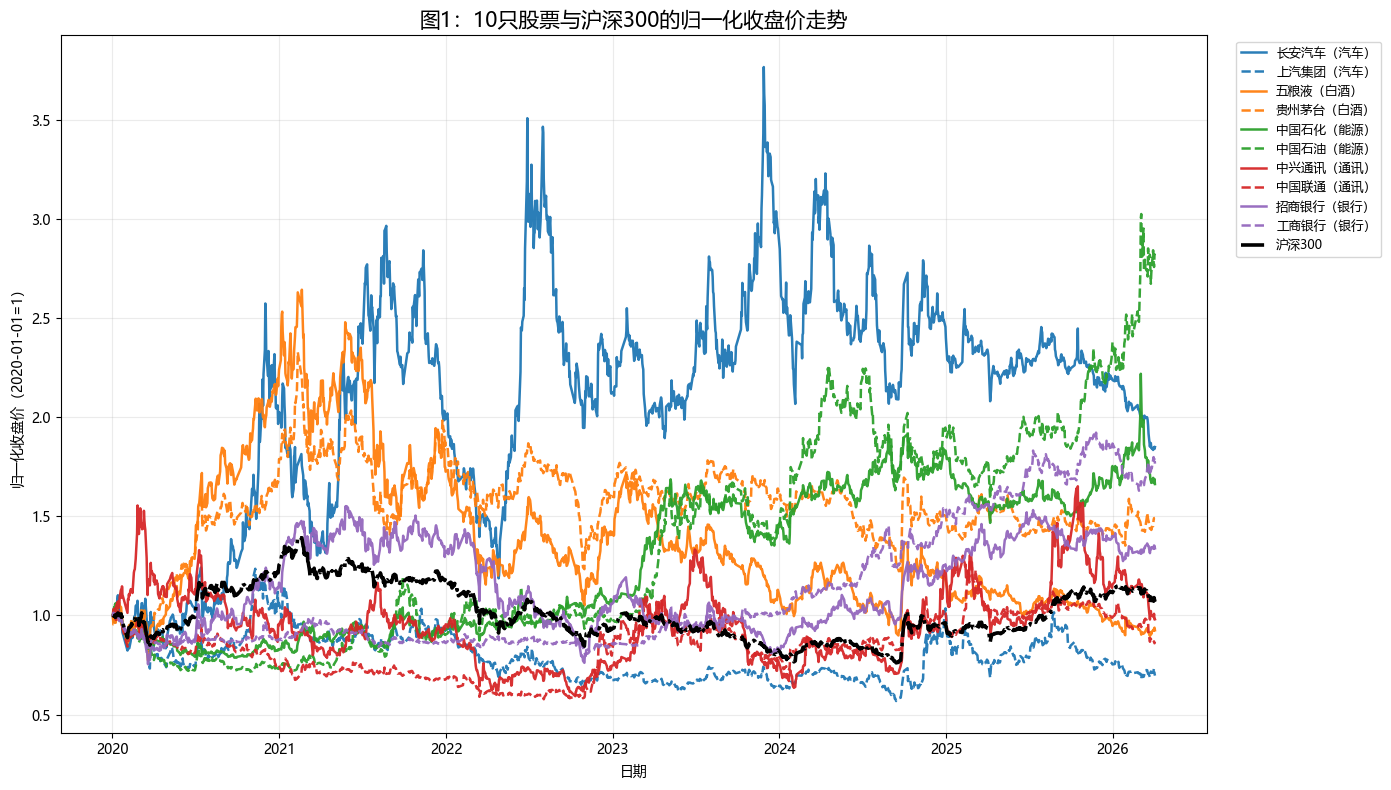

**图1 图后解读：**

1. 从归一化走势看，样本期末表现最强的股票是中国石油，期末归一化值约为2.82；表现相对最弱的是上汽集团，期末归一化值约为0.70。这说明不同个股在同一宏观环境下的累计涨跌幅存在明显分化，行业属性与个股基本面可能共同影响长期表现。

2. 沪深300在样本期末的归一化值约为1.07，可作为整体市场基准进行比较。若某些股票长期高于沪深300，说明其累计表现跑赢大盘；若明显低于沪深300，则说明其相对收益较弱。



已保存： d:\Microsoft VS Code\dshw-p01\output\fig1_normalized_close.png


In [4]:
# 准备图1数据
plot_df = stock_df[["date", "code", "name", "industry", "close"]].dropna().copy()
plot_df = plot_df.sort_values(["code", "date"])
plot_df["norm_close"] = plot_df.groupby("code")["close"].transform(lambda s: s / s.iloc[0])

hs300_plot = hs300[["date", "close"]].dropna().sort_values("date").copy()
hs300_plot["norm_close"] = hs300_plot["close"] / hs300_plot["close"].iloc[0]

industry_order = meta.sort_values(["industry", "code"])["industry"].drop_duplicates().tolist()
industry_colors = {ind: plt.cm.tab10(i % 10) for i, ind in enumerate(industry_order)}

fig, ax = plt.subplots(figsize=(14, 8))

for ind in industry_order:
    sub_meta = meta[meta["industry"] == ind].sort_values("code")
    for j, (_, mrow) in enumerate(sub_meta.iterrows()):
        sub = plot_df[plot_df["code"] == mrow["code"]]
        style = "-" if j == 0 else "--"
        ax.plot(
            sub["date"], sub["norm_close"],
            color=industry_colors[ind],
            linestyle=style,
            linewidth=1.8,
            alpha=0.95,
            label=f"{mrow['name']}（{ind}）"
        )

ax.plot(
    hs300_plot["date"], hs300_plot["norm_close"],
    color="black", linewidth=2.6, linestyle="-.",
    label="沪深300"
)

ax.set_title("图1：10只股票与沪深300的归一化收盘价走势", fontsize=15)
ax.set_xlabel("日期")
ax.set_ylabel("归一化收盘价（2020-01-01=1）")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(alpha=0.25)

fig.tight_layout()
fig1_path = OUTPUT_DIR / "fig1_normalized_close.png"
fig.savefig(fig1_path, dpi=200, bbox_inches="tight")
plt.show()

# 图后解读
end_perf = plot_df.sort_values("date").groupby(["code","name","industry"], as_index=False).tail(1)
best = end_perf.sort_values("norm_close", ascending=False).iloc[0]
worst = end_perf.sort_values("norm_close", ascending=True).iloc[0]
hs300_end = hs300_plot["norm_close"].iloc[-1]

show_text(
    "图1",
    [
        f"从归一化走势看，样本期末表现最强的股票是{best['name']}，期末归一化值约为{best['norm_close']:.2f}；表现相对最弱的是{worst['name']}，期末归一化值约为{worst['norm_close']:.2f}。这说明不同个股在同一宏观环境下的累计涨跌幅存在明显分化，行业属性与个股基本面可能共同影响长期表现。",
        f"沪深300在样本期末的归一化值约为{hs300_end:.2f}，可作为整体市场基准进行比较。若某些股票长期高于沪深300，说明其累计表现跑赢大盘；若明显低于沪深300，则说明其相对收益较弱。"
    ]
)
print("已保存：", fig1_path)

## 图 2：日收益率分布图

要求：

- 10 只股票收益率分面直方图（2 × 5）
- 每个子图叠加正态分布曲线
- 标注均值和标准差
- 写图后解读

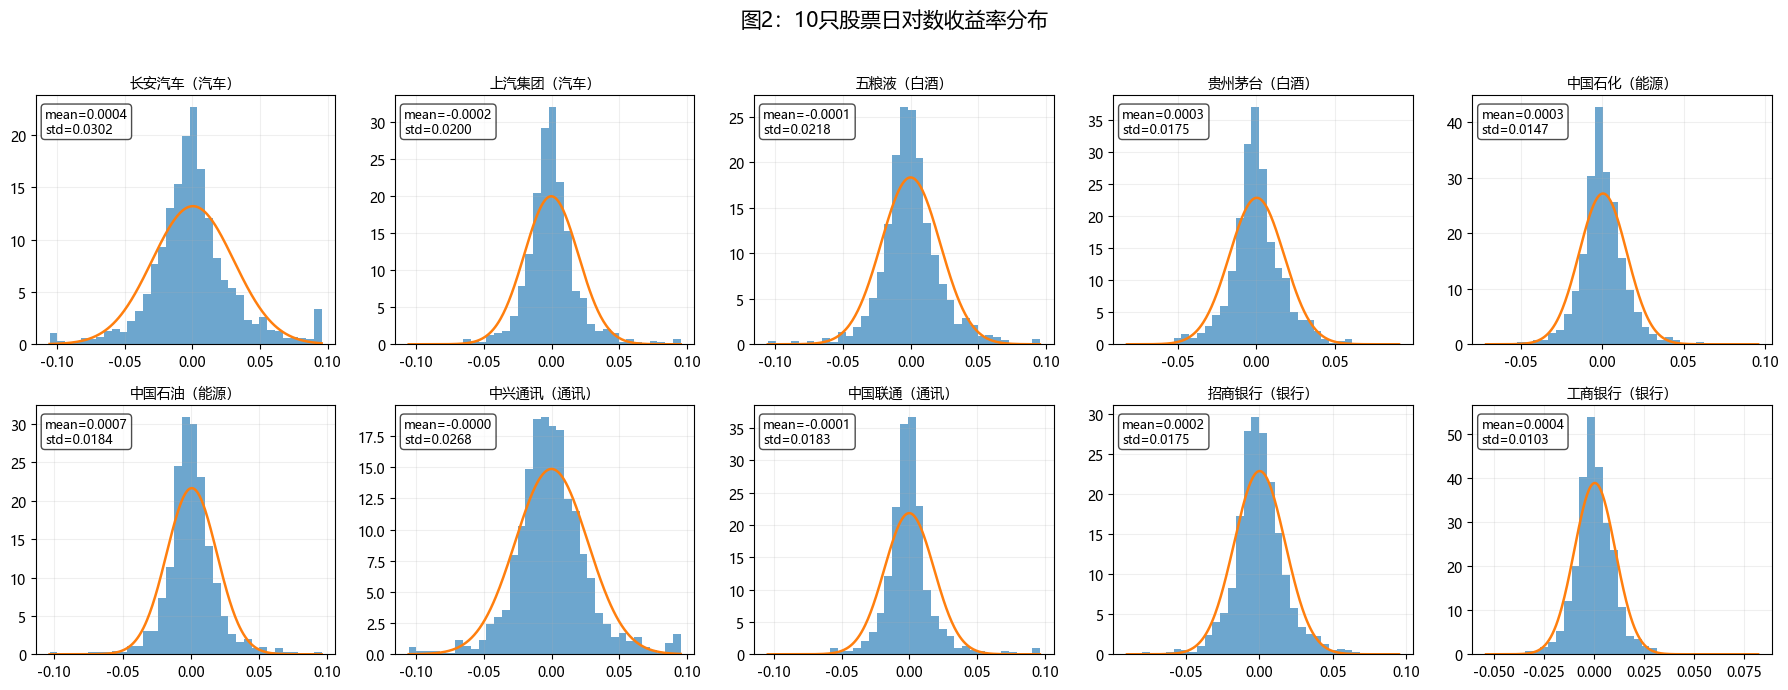

**图2 图后解读：**

1. 从分布形态看，不同股票的收益率离散程度并不一致，其中年化波动率最高的是长安汽车，约为48.01%；最低的是工商银行，约为16.27%。这说明样本股票的风险水平存在明显差异，行业景气度、个股弹性与市场关注度都可能影响日收益率波动。

2. 此外，峰度最高的股票是中国联通，其峰度约为7.51，表明该股票的收益率分布可能更容易出现尖峰厚尾现象。若直方图与叠加的正态曲线偏离较大，则说明实际收益率分布并不完全服从正态分布，这也是金融时间序列中的常见特征。



已保存： d:\Microsoft VS Code\dshw-p01\output\fig2_return_distribution.png


In [5]:
# 为图2准备排序
meta_sorted = meta.sort_values(["industry", "code"]).reset_index(drop=True)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for ax, (_, mrow) in zip(axes, meta_sorted.iterrows()):
    sub = stock_df.loc[stock_df["code"] == mrow["code"], "log_return"].dropna()
    mu = sub.mean()
    sigma = sub.std()

    ax.hist(sub, bins=35, density=True, alpha=0.65)
    if sigma > 0:
        x = np.linspace(sub.min(), sub.max(), 300)
        pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))
        ax.plot(x, pdf, linewidth=1.8)

    ax.set_title(f"{mrow['name']}（{mrow['industry']}）", fontsize=10)
    ax.text(
        0.03, 0.95,
        f"mean={mu:.4f}\nstd={sigma:.4f}",
        transform=ax.transAxes,
        va="top", ha="left", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
    )
    ax.grid(alpha=0.2)

for i in range(len(meta_sorted), len(axes)):
    axes[i].axis("off")

fig.suptitle("图2：10只股票日对数收益率分布", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.96])

fig2_path = OUTPUT_DIR / "fig2_return_distribution.png"
fig.savefig(fig2_path, dpi=200, bbox_inches="tight")
plt.show()

highest_vol = stats_df.sort_values("年化波动率", ascending=False).iloc[0]
lowest_vol = stats_df.sort_values("年化波动率", ascending=True).iloc[0]
highest_kurt = stats_df.sort_values("峰度", ascending=False).iloc[0]

show_text(
    "图2",
    [
        f"从分布形态看，不同股票的收益率离散程度并不一致，其中年化波动率最高的是{highest_vol['股票']}，约为{highest_vol['年化波动率']:.2%}；最低的是{lowest_vol['股票']}，约为{lowest_vol['年化波动率']:.2%}。这说明样本股票的风险水平存在明显差异，行业景气度、个股弹性与市场关注度都可能影响日收益率波动。",
        f"此外，峰度最高的股票是{highest_kurt['股票']}，其峰度约为{highest_kurt['峰度']:.2f}，表明该股票的收益率分布可能更容易出现尖峰厚尾现象。若直方图与叠加的正态曲线偏离较大，则说明实际收益率分布并不完全服从正态分布，这也是金融时间序列中的常见特征。"
    ]
)
print("已保存：", fig2_path)

## 图 3：收益率相关系数热力图

要求：

- 10 只股票日收益率相关系数矩阵热力图
- 标注具体数值
- 按行业对股票排序
- 讨论同一行业内相关性是否高于跨行业

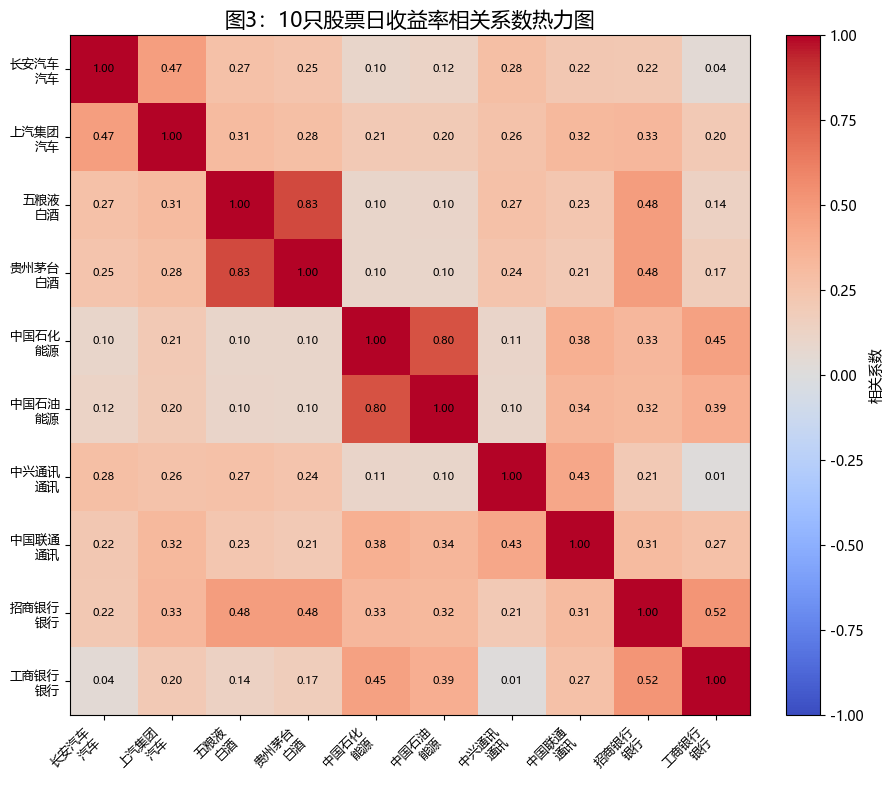

**图3 图后解读：**

1. 相关系数热力图显示，样本股票之间普遍存在一定程度的正相关，但相关性强弱并不完全一致。按照行业分组后可以观察到，同一行业内部股票的平均相关系数约为0.61，而跨行业平均相关系数约为0.24。

2. 如果同业平均相关性高于跨行业平均相关性，说明行业共同因子对收益率联动具有较强解释力；反之，则说明市场整体风险因子或个股特质在样本期内更突出。对于投资组合配置而言，跨行业配置通常更有助于分散非系统性风险。



已保存： d:\Microsoft VS Code\dshw-p01\output\fig3_corr_heatmap.png


In [6]:
# 构造相关矩阵
ret_wide = stock_df.pivot_table(index="date", columns="code", values="log_return")
ordered_codes = meta_sorted["code"].tolist()
ret_wide = ret_wide[ordered_codes]

label_map = {row["code"]: f"{row['name']}\n{row['industry']}" for _, row in meta_sorted.iterrows()}
corr_mat = ret_wide.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_mat.values, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(range(len(ordered_codes)))
ax.set_yticks(range(len(ordered_codes)))
ax.set_xticklabels([label_map[c] for c in ordered_codes], fontsize=9, rotation=45, ha="right")
ax.set_yticklabels([label_map[c] for c in ordered_codes], fontsize=9)

for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        ax.text(j, i, f"{corr_mat.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("图3：10只股票日收益率相关系数热力图", fontsize=15)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("相关系数")

fig.tight_layout()
fig3_path = OUTPUT_DIR / "fig3_corr_heatmap.png"
fig.savefig(fig3_path, dpi=200, bbox_inches="tight")
plt.show()

# 计算同业与跨行业平均相关性
code_to_ind = dict(zip(meta_sorted["code"], meta_sorted["industry"]))
pairs = []
for i, c1 in enumerate(ordered_codes):
    for j, c2 in enumerate(ordered_codes):
        if j <= i:
            continue
        corr_val = corr_mat.loc[c1, c2]
        same_ind = code_to_ind[c1] == code_to_ind[c2]
        pairs.append({"c1": c1, "c2": c2, "corr": corr_val, "same_industry": same_ind})
pairs_df = pd.DataFrame(pairs)

within_mean = pairs_df.loc[pairs_df["same_industry"], "corr"].mean()
across_mean = pairs_df.loc[~pairs_df["same_industry"], "corr"].mean()

show_text(
    "图3",
    [
        f"相关系数热力图显示，样本股票之间普遍存在一定程度的正相关，但相关性强弱并不完全一致。按照行业分组后可以观察到，同一行业内部股票的平均相关系数约为{within_mean:.2f}，而跨行业平均相关系数约为{across_mean:.2f}。",
        f"如果同业平均相关性高于跨行业平均相关性，说明行业共同因子对收益率联动具有较强解释力；反之，则说明市场整体风险因子或个股特质在样本期内更突出。对于投资组合配置而言，跨行业配置通常更有助于分散非系统性风险。"
    ]
)
print("已保存：", fig3_path)

## 图 4：宏观指标与股市关系

要求：

- 任选 1 项宏观指标
- 绘制其与沪深300月度收益率的散点图
- 叠加线性拟合线
- 标注 Pearson 相关系数
- 讨论关系方向和经济含义

C:\Users\Phyllis\AppData\Local\Temp\ipykernel_27400\4019819899.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hs300_monthly = hs300_monthly.set_index("date").resample("M").last().dropna().reset_index()


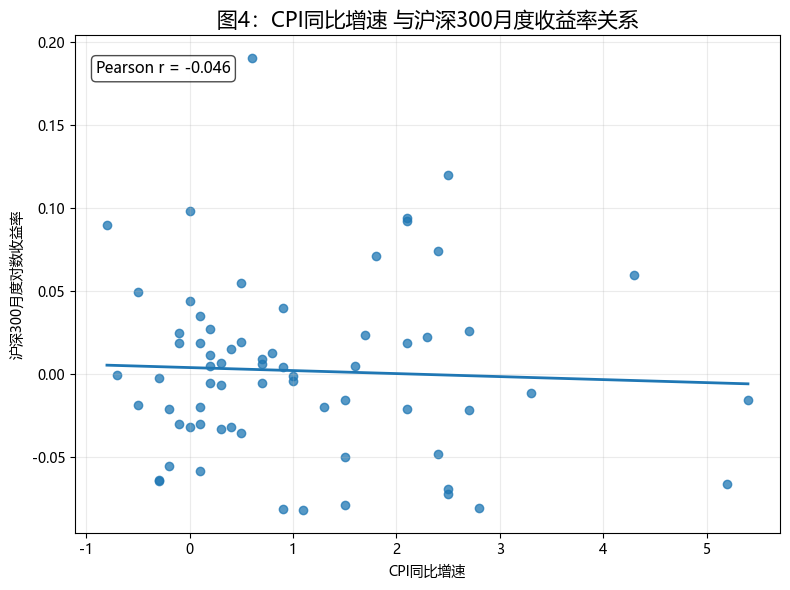

**图4 图后解读：**

1. 从散点图和拟合线看，CPI同比增速 与沪深300月度收益率呈现负相关，Pearson 相关系数约为 -0.046。这说明在样本期内，该宏观指标变化与股市月度表现之间存在一定方向性的联动，但相关系数的绝对值大小也提示我们这种关系未必非常强。

2. 从经济含义上看，宏观指标会通过盈利预期、融资成本、流动性或估值折现率影响股票市场。若使用的是 CPI，同比通胀变化可能影响实际利率和政策预期；若使用的是 LPR，利率水平变化则更直接影响企业融资成本与权益资产估值。



已保存： d:\Microsoft VS Code\dshw-p01\output\fig4_macro_vs_hs300.png


In [7]:
# 选择宏观指标：优先 CPI，同比；若不存在则用 1年期LPR
macro_choice = None
if (MACRO_DIR / "macro_cpi_yoy.csv").exists():
    macro_choice = pd.read_csv(MACRO_DIR / "macro_cpi_yoy.csv")
elif (MACRO_DIR / "macro_lpr_1y.csv").exists():
    macro_choice = pd.read_csv(MACRO_DIR / "macro_lpr_1y.csv")
else:
    raise FileNotFoundError("未找到宏观指标文件。")

macro_choice["date"] = pd.to_datetime(macro_choice["date"])
macro_name = str(macro_choice["indicator"].dropna().iloc[0]) if "indicator" in macro_choice.columns else "宏观指标"

# 宏观指标按月整理
macro_monthly = macro_choice.copy()
macro_monthly["month"] = macro_monthly["date"].dt.to_period("M")
macro_monthly = macro_monthly.sort_values("date").groupby("month", as_index=False).tail(1)
macro_monthly = macro_monthly[["month", "value"]].rename(columns={"value": "macro_value"})

# 沪深300月度对数收益率
hs300_monthly = hs300[["date", "close"]].dropna().copy().sort_values("date")
hs300_monthly = hs300_monthly.set_index("date").resample("M").last().dropna().reset_index()
hs300_monthly["month"] = hs300_monthly["date"].dt.to_period("M")
hs300_monthly["hs300_mret"] = np.log(hs300_monthly["close"] / hs300_monthly["close"].shift(1))

scatter_df = hs300_monthly.merge(macro_monthly, on="month", how="inner").dropna(subset=["hs300_mret", "macro_value"]).copy()

x = scatter_df["macro_value"].to_numpy()
y = scatter_df["hs300_mret"].to_numpy()
corr = np.corrcoef(x, y)[0, 1] if len(scatter_df) >= 2 else np.nan

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, alpha=0.75)

if len(scatter_df) >= 2:
    coef = np.polyfit(x, y, deg=1)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = coef[0] * x_line + coef[1]
    ax.plot(x_line, y_line, linewidth=2)

ax.set_title(f"图4：{macro_name} 与沪深300月度收益率关系", fontsize=15)
ax.set_xlabel(macro_name)
ax.set_ylabel("沪深300月度对数收益率")
ax.grid(alpha=0.25)

ax.text(
    0.03, 0.95,
    f"Pearson r = {corr:.3f}",
    transform=ax.transAxes,
    va="top", ha="left", fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
)

fig.tight_layout()
fig4_path = OUTPUT_DIR / "fig4_macro_vs_hs300.png"
fig.savefig(fig4_path, dpi=200, bbox_inches="tight")
plt.show()

direction = "正相关" if pd.notna(corr) and corr > 0 else "负相关" if pd.notna(corr) and corr < 0 else "相关性不明显"

show_text(
    "图4",
    [
        f"从散点图和拟合线看，{macro_name} 与沪深300月度收益率呈现{direction}，Pearson 相关系数约为 {corr:.3f}。这说明在样本期内，该宏观指标变化与股市月度表现之间存在一定方向性的联动，但相关系数的绝对值大小也提示我们这种关系未必非常强。",
        f"从经济含义上看，宏观指标会通过盈利预期、融资成本、流动性或估值折现率影响股票市场。若使用的是 CPI，同比通胀变化可能影响实际利率和政策预期；若使用的是 LPR，利率水平变化则更直接影响企业融资成本与权益资产估值。"
    ]
)
print("已保存：", fig4_path)

## 图 5（选做）：财务指标跨公司对比

这里选用 **ROE** 作为财务指标，绘制最近 5 年的折线图，并按行业分组着色。  
这部分是选做，但我一并放进 notebook，便于你直接完成更完整的作业。

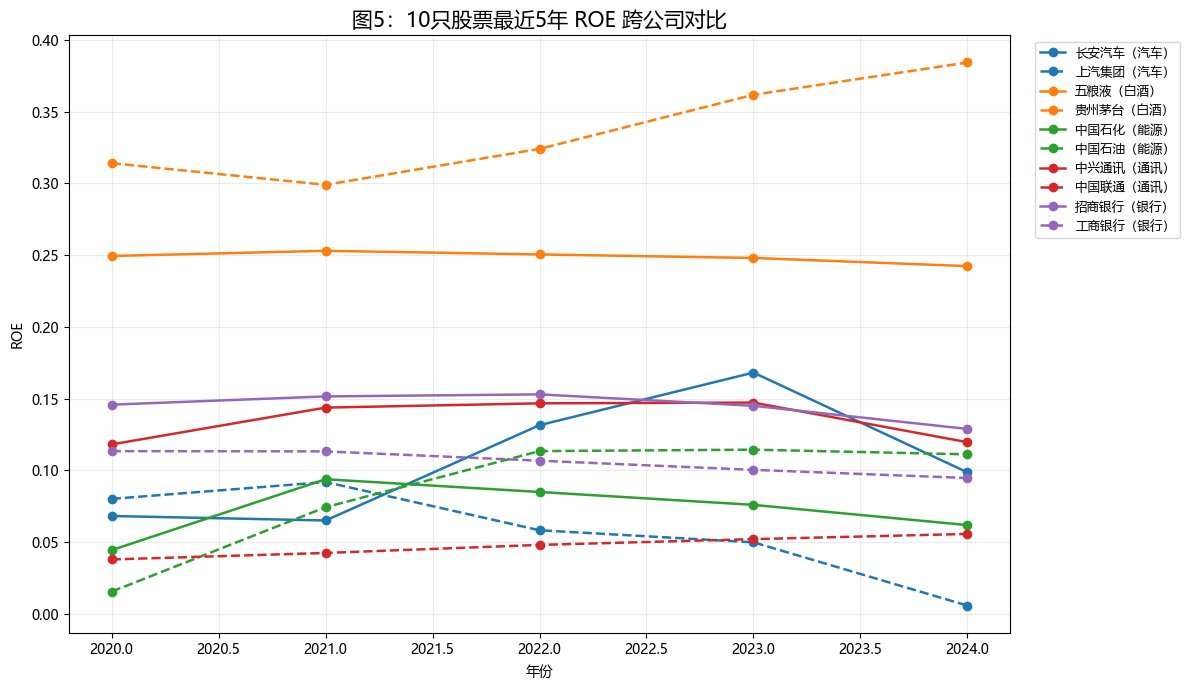

**图5 图后解读：**

1. 从最近五年的 ROE 折线看，不同行业之间的盈利能力水平存在明显差异。以最近一年为例，平均 ROE 最高的行业是白酒，约为0.31；平均 ROE 最低的行业是汽车，约为0.05。

2. ROE 反映股东权益的使用效率，因此它不仅体现行业盈利模式差异，也会影响资本市场对公司质量的定价。若某一行业 ROE 长期较高且波动较小，通常意味着该行业的盈利能力和资本回报更稳健。



已保存： d:\Microsoft VS Code\dshw-p01\output\fig5_roe_comparison.png


In [8]:
if finance_df.empty:
    display(Markdown("**提示：** 未找到 `data/finance/finance_long.csv`，因此图5跳过。"))
else:
    finance_plot = finance_df.copy()
    finance_plot = finance_plot.merge(universe[["code", "name", "industry"]], on="code", how="left")
    finance_plot = finance_plot[finance_plot["indicator"] == "ROE"].copy()
    finance_plot["year"] = pd.to_numeric(finance_plot["year"], errors="coerce")
    finance_plot["value"] = pd.to_numeric(finance_plot["value"], errors="coerce")
    finance_plot = finance_plot.dropna(subset=["year", "value"]).sort_values(["industry", "code", "year"])

    fig, ax = plt.subplots(figsize=(12, 7))
    for ind in finance_plot["industry"].dropna().drop_duplicates():
        sub_meta = finance_plot[finance_plot["industry"] == ind][["code", "name"]].drop_duplicates().sort_values("code")
        for j, (_, mrow) in enumerate(sub_meta.iterrows()):
            sub = finance_plot[(finance_plot["industry"] == ind) & (finance_plot["code"] == mrow["code"])]
            style = "-" if j == 0 else "--"
            ax.plot(
                sub["year"], sub["value"],
                color=industry_colors.get(ind, None),
                linestyle=style,
                marker="o",
                linewidth=1.8,
                label=f"{mrow['name']}（{ind}）"
            )

    ax.set_title("图5：10只股票最近5年 ROE 跨公司对比", fontsize=15)
    ax.set_xlabel("年份")
    ax.set_ylabel("ROE")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)

    fig.tight_layout()
    fig5_path = OUTPUT_DIR / "fig5_roe_comparison.png"
    fig.savefig(fig5_path, dpi=200, bbox_inches="tight")
    plt.show()

    roe_2024 = finance_plot[finance_plot["year"] == finance_plot["year"].max()].copy()
    ind_mean = roe_2024.groupby("industry", as_index=False)["value"].mean().sort_values("value", ascending=False)

    if not ind_mean.empty:
        best_ind = ind_mean.iloc[0]
        worst_ind = ind_mean.iloc[-1]
        show_text(
            "图5",
            [
                f"从最近五年的 ROE 折线看，不同行业之间的盈利能力水平存在明显差异。以最近一年为例，平均 ROE 最高的行业是{best_ind['industry']}，约为{best_ind['value']:.2f}；平均 ROE 最低的行业是{worst_ind['industry']}，约为{worst_ind['value']:.2f}。",
                f"ROE 反映股东权益的使用效率，因此它不仅体现行业盈利模式差异，也会影响资本市场对公司质量的定价。若某一行业 ROE 长期较高且波动较小，通常意味着该行业的盈利能力和资本回报更稳健。"
            ]
        )
        print("已保存：", fig5_path)

## 完成说明

运行完本 notebook 后，你可以到 `output/` 目录检查以下成果：

- `descriptive_stats.csv`
- `fig1_normalized_close.png`
- `fig2_return_distribution.png`
- `fig3_corr_heatmap.png`
- `fig4_macro_vs_hs300.png`
- `fig5_roe_comparison.png`（若存在财务数据）

如果你后面还要做第五部分 CAPM / 回归分析，可以直接在这个 notebook 的基础上继续衔接。

In [9]:
print("第四部分全部完成。你现在可以检查 output/ 目录中的文件：")
for p in [
    OUTPUT_DIR / "descriptive_stats.csv",
    OUTPUT_DIR / "fig1_normalized_close.png",
    OUTPUT_DIR / "fig2_return_distribution.png",
    OUTPUT_DIR / "fig3_corr_heatmap.png",
    OUTPUT_DIR / "fig4_macro_vs_hs300.png",
    OUTPUT_DIR / "fig5_roe_comparison.png",
]:
    print("-", p)

第四部分全部完成。你现在可以检查 output/ 目录中的文件：
- d:\Microsoft VS Code\dshw-p01\output\descriptive_stats.csv
- d:\Microsoft VS Code\dshw-p01\output\fig1_normalized_close.png
- d:\Microsoft VS Code\dshw-p01\output\fig2_return_distribution.png
- d:\Microsoft VS Code\dshw-p01\output\fig3_corr_heatmap.png
- d:\Microsoft VS Code\dshw-p01\output\fig4_macro_vs_hs300.png
- d:\Microsoft VS Code\dshw-p01\output\fig5_roe_comparison.png
